
# 03_02 Group data with clustering algorithms

In this notebook, you will use K-Means clustering to find structure in the classic Iris dataset.


## Load the Iris dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans

url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
df = pd.read_csv(url)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Prepare numeric features for clustering

In [13]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Scale the features

In [14]:
scaler = sklearn.preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]


array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

## Fit a K-Means clustering model

In [15]:
kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto')
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_


## Compare clusters to true species labels

In [16]:
df["cluster"] = cluster_labels

crosstab = pd.crosstab(df["cluster"], df["species"])
crosstab


species,setosa,versicolor,virginica
cluster,,,
0,1,37,8
1,49,0,0
2,0,13,42


## Visualize clusters in feature space

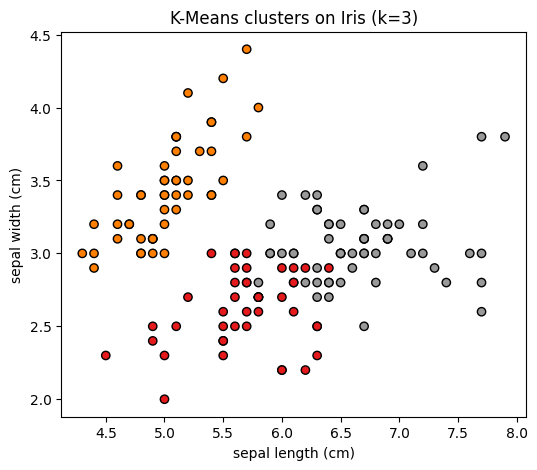

In [17]:

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    df["sepal_length"],
    df["sepal_width"],
    c=df["cluster"],
    cmap=plt.cm.Set1,
    edgecolor="k"
)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("K-Means clusters on Iris (k=3)")
plt.show()


## Choose the number of clusters using hte "Elbow Method"

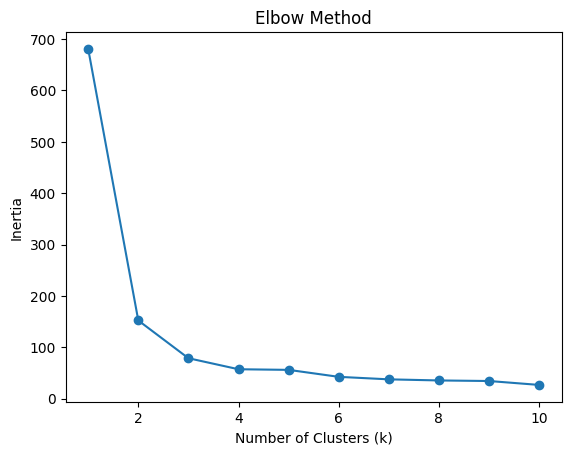

In [18]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=1)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()